### Building Chatbot with Multiple Tools using LangGraph

#### Aim
- Create a Chatbot with tool capabilities from arxiv, wikipedia search and some functions.

In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper

In [3]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [7]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [8]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [9]:
wiki.invoke("What is machine learning?")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML fi'

In [11]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [13]:
### Tavily search tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [14]:
tavily.invoke("Provide me the recent AI news")

[{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
  'url': 'https://www.artificialintelligence-news.com/',
  'content': "#### Applications\n\n### Thailand becomes one of the first in Asia to get the Sora app\n\nEntertainment & Media\n\nOctober 30, 2025\n\n### Malaysia launches Ryt Bank, its first AI-powered bank\n\nFinance AI\n\nAugust 26, 2025\n\n### Google’s Veo 3 AI video creation tools are now widely available\n\nAI in Action\n\nJuly 29, 2025\n\n#### Computer Vision\n\n### US and Japan announce sweeping AI and tech collaboration\n\nArtificial Intelligence\n\nApril 11, 2024\n\n### UK and Canada sign AI compute agreement\n\nArtificial Intelligence\n\nJanuary 31, 2024\n\n### Quantum AI represents a ‘transformative advancement’\n\nAI Hardware & Chips\n\nNovember 14, 2023\n\n#### Machine Learning\n\n### How AI is changing the way we travel\n\nArtificial Intelligence\n\nOctober 7, 2025 [...] ### Hitachi bets on industrial expertise to win the physical AI r

In [15]:
### Combine all the tools in the list
tools = [arxiv, wiki, tavily]

In [20]:
## Initialize LLM Model

from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="qwen/qwen3-32b", reasoning_format="hidden")

llm_with_tools = llm_groq.bind_tools(tools)

In [21]:
from pprint import pprint
from langchain_core.messages import HumanMessage, AIMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI news?")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'tzq50ahkh', 'function': {'arguments': '{"query":"recent AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 200, 'prompt_tokens': 400, 'total_tokens': 600, 'completion_time': 0.59449997, 'completion_tokens_details': {'reasoning_tokens': 171}, 'prompt_time': 0.015939389, 'prompt_tokens_details': None, 'queue_time': 0.171274427, 'total_time': 0.610439359}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cb79c-9d55-79b3-b708-ba1a011afdfe-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI news'}, 'id': 'tzq50ahkh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 400, 'output_tokens': 200, 'total_tokens': 600, 'output_token_details': {'reasoning': 1

In [22]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI news?")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': '3hf37v2g6',
  'type': 'tool_call'}]

In [23]:
### State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

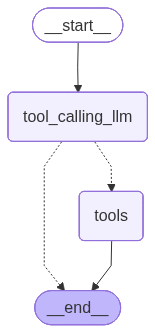

In [24]:
### Entire Chatbot with LangGraph

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Builder Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool_call -> tools_conditin routes to END
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
messages = graph.invoke({"messages": HumanMessage(content="1706.03762")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (3p9qgd14s)
 Call ID: 3p9qgd14s
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [27]:
messages = graph.invoke({"messages": HumanMessage(content="Provide me the the top 10 recent AI news for March 5th 2026")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Provide me the the top 10 recent AI news for March 5th 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (ph2baa452)
 Call ID: ph2baa452
  Args:
    query: top 10 recent AI news March 5th 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Top 10 AI Predictions For The Channel In 2026 - CRN", "url": "https://www.crn.com/news/ai/2026/top-10-ai-predictions-for-the-channel-in-2026", "content": "Large enterprises opting for on-premises data center investments to assist with AI inferencing’s data gravity–the idea that bringing compute to the data rather than moving massive datasets to the cloud is cheaper and more secure–spells good news for the likes of Dell, Hewlett Packard Enterprise and IBM. The growth in data center interconnect (DCI) and scale-across

In [28]:
messages = graph.invoke({"messages": HumanMessage(content="What is Machine Learning?")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is Machine Learning?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (azxaj8rw2)
 Call ID: azxaj8rw2
  Args:
    query: Machine Learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi
